In [8]:
!pip install pandas numpy scikit-learn matplotlib yfinance

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

In [58]:
stock = input("Enter stock symbol (ex: TCS.NS, INFY.NS, RELIANCE.NS):")
data = yf.download(stock, start ="2020-01-01", end="2024-01-01")
data.head()

Enter stock symbol (ex: TCS.NS, INFY.NS, RELIANCE.NS): INFY.NS


[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,INFY.NS,INFY.NS,INFY.NS,INFY.NS,INFY.NS
Date,,,,,
2020-01-01,633.151184,635.857897,629.456345,631.561560,2112415
2020-01-02,631.303711,636.545221,628.038506,634.912644,5658200
2020-01-03,641.013428,642.731962,630.616314,630.616314,7882938
2020-01-06,634.869629,647.715686,632.850372,641.099317,6519403
2020-01-07,625.460754,638.091943,623.054764,634.139334,7899363


In [59]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 992 entries, 2020-01-01 to 2023-12-29
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Close, INFY.NS)   992 non-null    float64
 1   (High, INFY.NS)    992 non-null    float64
 2   (Low, INFY.NS)     992 non-null    float64
 3   (Open, INFY.NS)    992 non-null    float64
 4   (Volume, INFY.NS)  992 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 46.5 KB


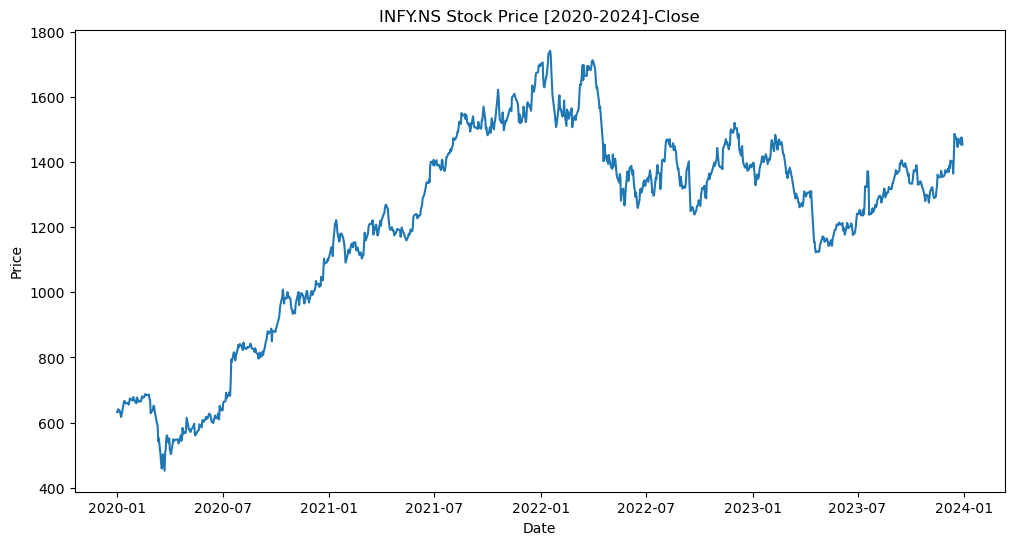

In [73]:
plt.figure(figsize=(12,6))
plt.plot(data[['Close']])
plt.title(f"{stock} Stock Price [2020-2024]-Close")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

[]

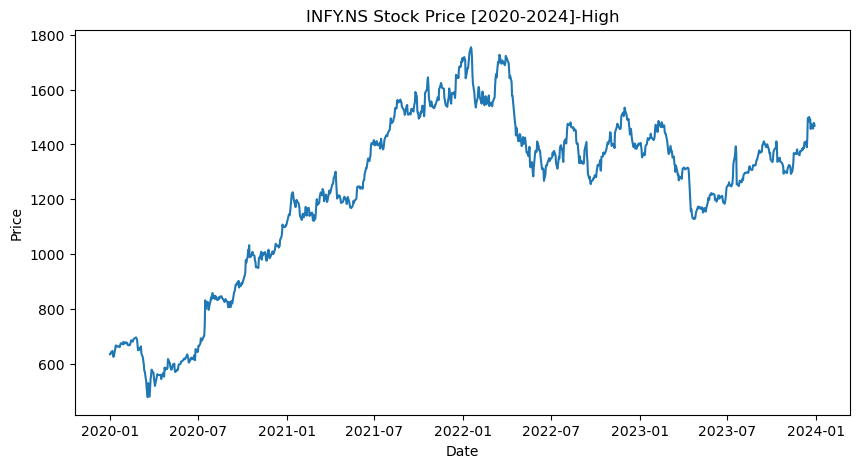

In [65]:
plt.figure(figsize=(10,5))
plt.plot(data['High'])
plt.title(f"{stock} Stock Price [2020-2024]-High")
plt.xlabel("Date")
plt.ylabel("Price")
plt.plot()

[]

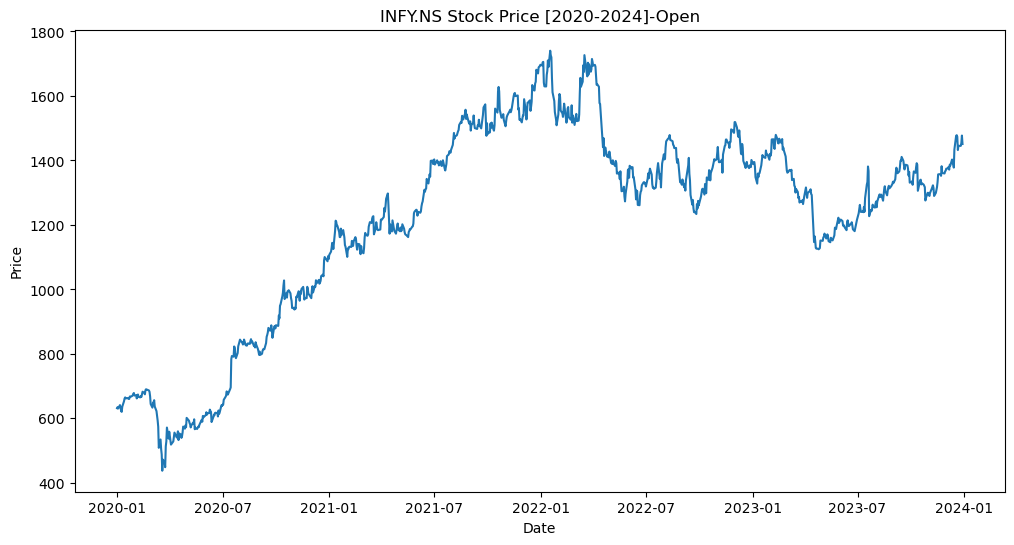

In [66]:
plt.figure(figsize=(12,6))
plt.plot(data["Open"])
plt.title(f"{stock} Stock Price [2020-2024]-Open")
plt.xlabel("Date")
plt.ylabel("Price")
plt.plot()

[]

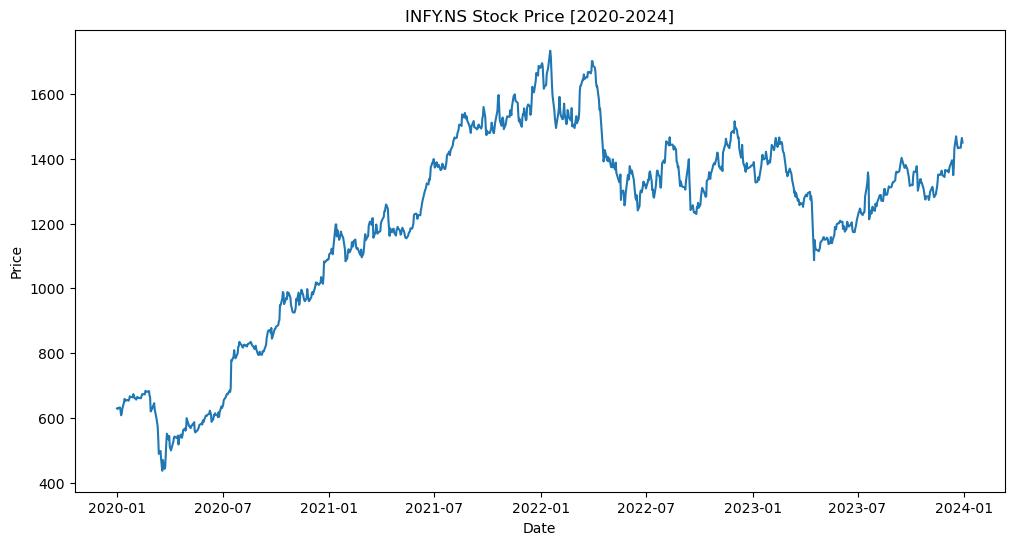

In [67]:
plt.figure(figsize=(12,6))
plt.plot(data["Low"])
plt.title(f"{stock} Stock Price [2020-2024]")
plt.xlabel("Date")
plt.ylabel("Price")
plt.plot()

[]

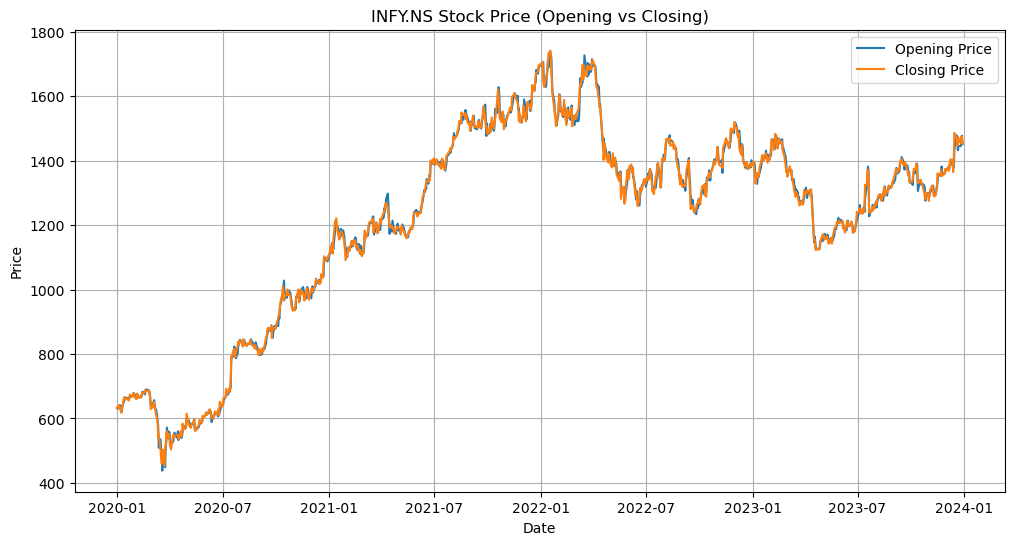

In [68]:
plt.figure(figsize=(12,6))
plt.plot(data['Open'], label='Opening Price')
plt.plot(data['Close'], label = "Closing Price")
plt.title(f"{stock} Stock Price (Opening vs Closing)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid('true')
plt.plot()

[]

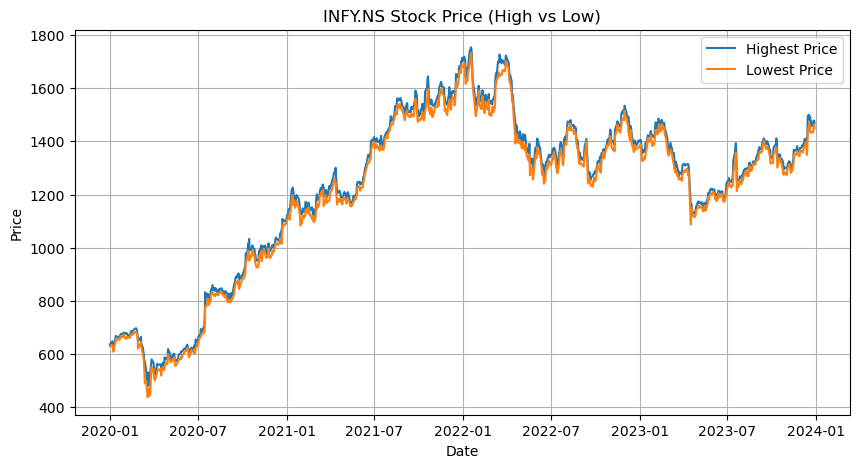

In [69]:
plt.figure(figsize=(10,5))
plt.plot(data['High'], label='Highest Price')
plt.plot(data['Low'], label='Lowest Price')
plt.title(f"{stock} Stock Price (High vs Low)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid('true')
plt.plot()

In [18]:
data.columns = data.columns.get_level_values(0)
data.head()

data['Prediction'] = data['Close'].shift(-10)
data[['Close','Prediction']].head(15)

Price,Close,Prediction
Date,,
2020-01-01,1866.114136,1917.165894
2020-01-02,1857.548218,1927.410889
2020-01-03,1894.566528,1910.451416
2020-01-06,1894.394531,1868.481323
2020-01-07,1899.043701,1869.084106
2020-01-08,1941.573120,1899.947632
2020-01-09,1906.361694,1890.499390
2020-01-10,1905.672852,1883.984497
2020-01-13,1885.699707,1871.775269


In [19]:
data[['Close','Prediction']].head(15)

Price,Close,Prediction
Date,,
2020-01-01,1866.114136,1917.165894
2020-01-02,1857.548218,1927.410889
2020-01-03,1894.566528,1910.451416
2020-01-06,1894.394531,1868.481323
2020-01-07,1899.043701,1869.084106
2020-01-08,1941.573120,1899.947632
2020-01-09,1906.361694,1890.499390
2020-01-10,1905.672852,1883.984497
2020-01-13,1885.699707,1871.775269


In [20]:
data[['Close','Prediction']].tail(15)

Price,Close,Prediction
Date,,
2023-12-08,3377.626953,3561.376953
2023-12-11,3392.714600,3534.880859
2023-12-12,3419.909424,3549.456055
2023-12-13,3346.754150,3538.932129
2023-12-14,3415.392578,3532.878662
2023-12-15,3595.836182,NaN
2023-12-18,3594.159912,NaN
2023-12-19,3554.112305,NaN
2023-12-20,3520.446045,NaN


In [21]:
x = data[['Close']][:-10]
y = data['Prediction'] [:-10]

print(x.head())
print(y.head())


Price             Close
Date                   
2020-01-01  1866.114136
2020-01-02  1857.548218
2020-01-03  1894.566528
2020-01-06  1894.394531
2020-01-07  1899.043701
Date
2020-01-01    1917.165894
2020-01-02    1927.410889
2020-01-03    1910.451416
2020-01-06    1868.481323
2020-01-07    1869.084106
Name: Prediction, dtype: float64


In [22]:
print(x.shape)
print(y.shape)

(982, 1)
(982,)


In [23]:
from sklearn.model_selection import train_test_split
# split data
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

print("Training data:", x_train.shape)
print("Testing data:", x_test.shape)

Training data: (785, 1)
Testing data: (197, 1)


In [24]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(x_train, y_train)

LinearRegression()

In [29]:
predictions = model.predict(x_test)
print(predictions[:10])

[2952.45357361 2901.89617538 2998.55753695 3310.12944249 1587.45542403
 2898.50769232 3075.32212362 2903.53183155 3256.0784626  3202.7155945 ]


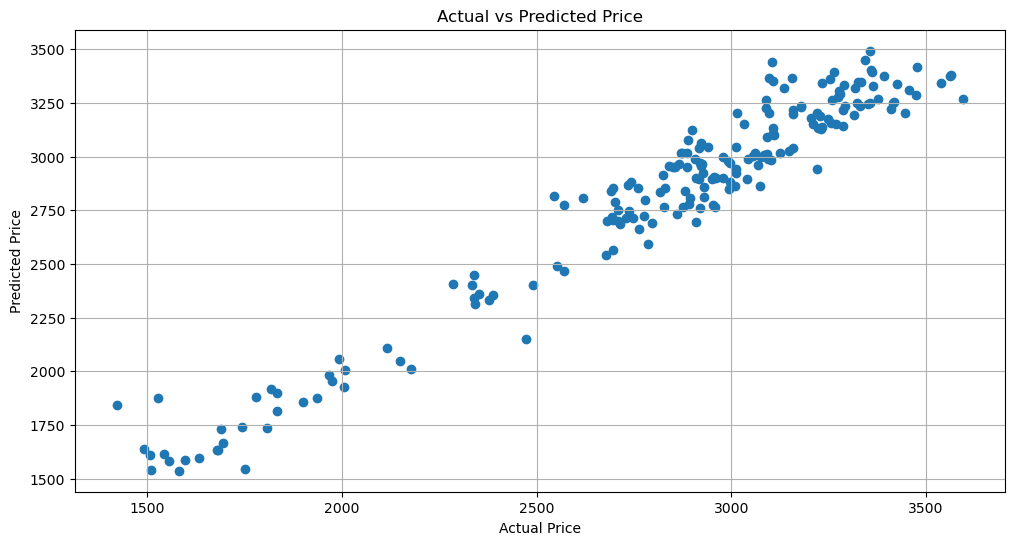

In [37]:
plt.figure(figsize=(12,6))

plt.scatter(y_test, predictions)
plt.title("Actual vs Predicted Price")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.grid('true')

plt.show()


In [40]:
from sklearn.metrics import mean_squared_error

error = mean_squared_error(y_test, predictions)

print("Model's error:", error)

rmse = np.sqrt(error)
print("Root Mean Squared Error:", rmse)
print("Model's prediction is off by about ₹",rmse," on average.")

Model's error: 14743.635762161015
Root Mean Squared Error: 121.42337403548386
Model's prediction is off by about ₹ 121.42337403548386  on average.


In [42]:
future = data[['Close']][:-10]
future_predictions = model.predict(future)
future_predictions[:10]

array([1908.40465761, 1900.099501  , 1935.99091014, 1935.82414896,
       1940.3317901 , 1981.56653997, 1947.4270109 , 1946.75913769,
       1927.39401023, 1941.20820356])

In [43]:
future_x = data[['Close']].tail(10)
future_predictions = model.predict(future_x)

future_predictions

array([3585.47097224, 3583.84573125, 3545.01724227, 3512.37584169,
       3519.10262561, 3552.06074225, 3526.37123542, 3540.50273658,
       3530.2991773 , 3524.42998851])

In [44]:
last_date = data.index[-1]
future_dates = pd.date_range(start = last_date, periods=11, freq='B')[1:]

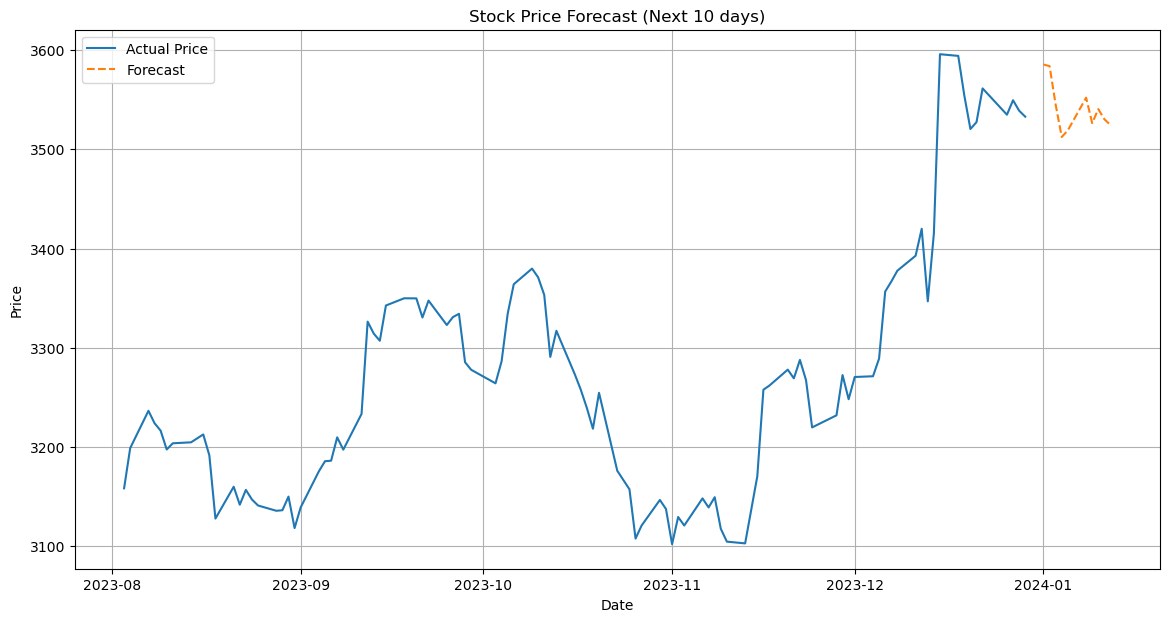

In [55]:
plt.figure(figsize=(14,7))
plt.plot(data['Close'].tail(100), label='Actual Price')

plt.plot(future_dates, future_predictions, label='Forecast', linestyle='dashed')

plt.title('Stock Price Forecast (Next 10 days)')
plt.xlabel("Date")
plt.ylabel('Price')
plt.grid('true')
plt.legend()
plt.show()
          

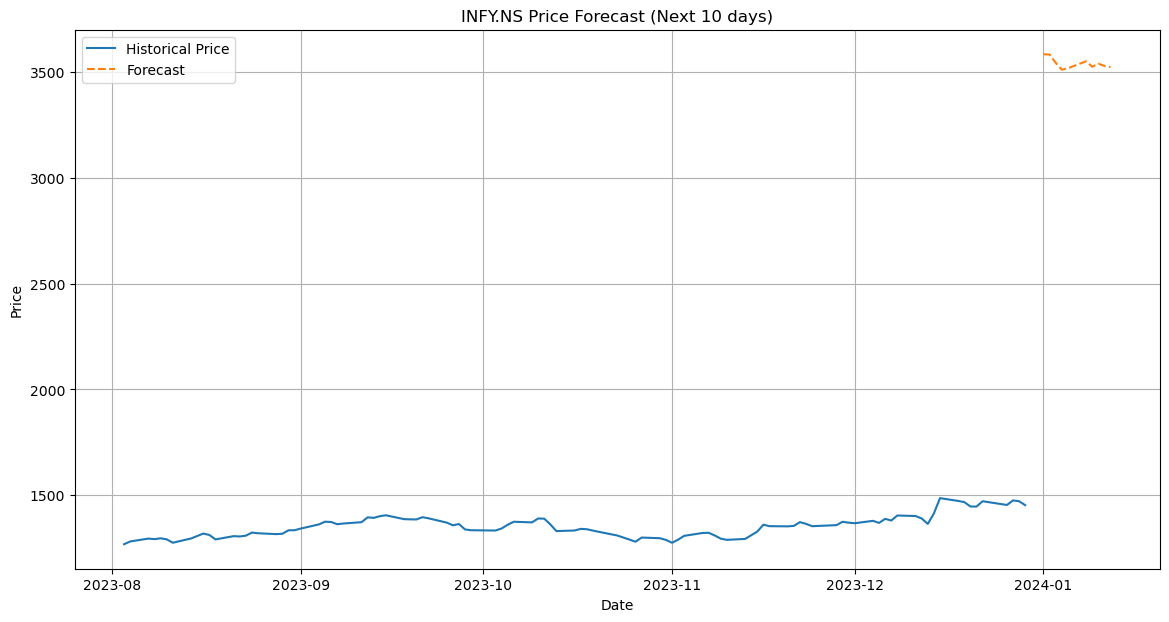

In [80]:
plt.figure(figsize=(14,7))
plt.plot(data.index[-100:], data['Close'].tail(100), label='Historical Price')

plt.plot(future_dates, future_predictions, label='Forecast', linestyle='dashed')

plt.title(f"{stock} Price Forecast (Next 10 days)")
plt.xlabel("Date")
plt.ylabel('Price')
plt.grid('true')
plt.legend()
plt.show()
          

In [81]:
from sklearn.metrics import r2_score
r2=r2_score(y_test, predictions)
#Measures how well a linear regression model explains the variance
print("R2 score:", r2)
print()
print("Score   Meaning")
print("0.8     very good")
print("0.5     moderate")
print("<0      poor")

R2 score: 0.9470024934044438

Score   Meaning
0.8     very good
0.5     moderate
<0      poor
